In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print(np.__version__)

2.3.3


explained: [0.15102127 0.1475879  0.14509222 0.14487049 0.14012654 0.13664912
 0.13465246]


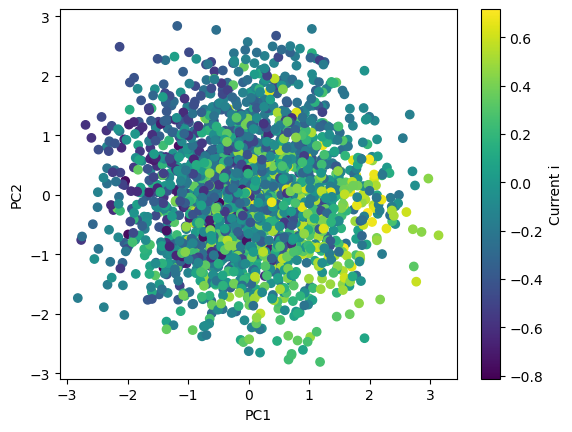

In [22]:
num_batches = 2
data_l = []
I_l = []
for i in range(num_batches):
    fp = f'/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni/batch_{i}.npz'
    batch = np.load(fp)
    data_l.append(batch['inputs'] )
    I_l.append(batch['currents'])

X = np.concatenate(data_l, axis=0)
y = np.concatenate(I_l, axis=0)
input_idx = 0

X = X[..., [i for i in range(X.shape[1]) if i != input_idx]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
print(f'explained: {explained}')

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Current i')
plt.show()